In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy 
from scipy.stats import gaussian_kde

path_to_data = os.environ.get('STELLAREV_DATA', os.path.join('..', 'master_Prot0.dat'))  # raw table, one directory above the repo
directory_output_name = './preprocessing_output_akima/'
directory_plot_examples = './plots_examples/akima/'
columns_to_drop = [' Xcen',
                ' Prot (fast)',
                ' Bcoronal(fast)', ' dMdt(fast)',
                ' Prot(m1.00_zh000y264106d0_0.77139421857871FK_CALIBRATED.out)',
                ' Bcoronal(m1.00_zh000y264106d0_0.77139421857871FK_CALIBRATED.out)',
                ' dM/dt(m1.00_zh000y264106d0_0.77139421857871FK_CALIBRATED.out)']
initial_conditions = ['Mstar', 'FeH', 'PMMA', 'PMMB', 'PMMM'] 
output_cols = ['logTeff', 'Prot_mid', 'Bcoronal_mid', 'Patm', 'tau_cz', 'dMdt_mid', 'luminosity']
# index_logTeff = output_cols.index('logTeff')
max_time = 13.8 # Gyr
val_percentage = 0.0
split = False # whether to apply log10 only for age<1 Gyr or for all ages
plot_examples = True # whether to plot examples of the original and new age distributions for a few simulations
SEED = 12
# np.random.seed(SEED)


#### utilities functions
def build_grouped_df(keys):
    frames = [grouped.get_group(k) for k in keys]
    df_flat = pd.concat(frames).reset_index(drop=True)
    # Group by simulation, collect Age and output vector arrays
    grouped_df = (
        df_flat.groupby(initial_conditions)
        .apply(lambda g: pd.Series({
            'Age': g['Age'].values,
            'output': g[output_cols].values
        }))
        .reset_index()
    )
    return grouped_df

def log10_func(arr):
    arr[:, 1:] = np.log10(arr[:, 1:])
    return arr

def kde_func(x, max_length_new_time):
    kde = gaussian_kde(x)
    cdf_0 = np.array([kde.integrate_box_1d(-np.inf, xi) for xi in x])
    u = np.linspace(0, 1, max_length_new_time)
    new_t = np.interp(u, cdf_0, x)
    return new_t

def split_log10(arr, split=False):
    arr = np.copy(arr)
    if split:
        #we apply log only for age<1 Gyr
        arr[arr < 1] = np.log10(arr[arr < 1])
        return arr
    else:
        return np.log10(arr)


In [2]:
data = np.loadtxt(path_to_data)
columns = pd.read_csv(path_to_data).columns.tolist()
df = pd.DataFrame(data, columns=columns)    
df = df.drop(columns_to_drop, axis=1)
df = df.rename(columns={'# Mstar': 'Mstar',
                        ' Age(Gyr)': 'Age',
                        ' [Fe/H]': 'FeH',
                        ' PMMA': 'PMMA',
                        ' PMMB': 'PMMB',
                        ' PMMM': 'PMMM',
                        ' log(Teff)': 'logTeff',
                        ' Patm': 'Patm',
                        ' tau_cz': 'tau_cz',
                        ' luminosity': 'luminosity',
                        ' Prot(mid)': 'Prot_mid', 
                        ' Bcoronal(mid)': 'Bcoronal_mid', 
                        ' dM/dt(mid)': 'dMdt_mid'
                        })
df.head()

,Mstar,Age,FeH,PMMA,PMMB,PMMM,logTeff,Patm,tau_cz,luminosity,Prot_mid,Bcoronal_mid,dMdt_mid
0,0.2,0.000002,0.0,1.0,1.0,0.1,3.518624,20869.8333,14836725.5,1.212088,0.24015,4.592024,2.291985e-13
1,0.2,0.000004,0.0,1.0,1.0,0.1,3.518914,21182.2115,14696106.5,1.183258,0.24015,4.626263,2.237471e-13
2,0.2,0.000006,0.0,1.0,1.0,0.1,3.519059,21422.2045,14696301.7,1.161439,0.24015,4.652397,2.196211e-13
3,0.2,0.000007,0.0,1.0,1.0,0.1,3.519116,21700.8378,14703502.2,1.136298,0.24015,4.682556,2.148672e-13
4,0.2,0.000009,0.0,1.0,1.0,0.1,3.519172,21981.8141,14710250.5,1.111776,0.24015,4.712772,2.102302e-13


In [3]:

#shuffle the dataframe
print('The columns of the dataframe are:', df.columns)

#Apply filtering 
print('Filtering to max age:', max_time, 'Gyr')
df = df[df['Age'] <= max_time]


The columns of the dataframe are: Index(['Mstar', 'Age', 'FeH', 'PMMA', 'PMMB', 'PMMM', 'logTeff', 'Patm',
       'tau_cz', 'luminosity', 'Prot_mid', 'Bcoronal_mid', 'dMdt_mid'],
      dtype='object')
Filtering to max age: 13.8 Gyr


In [4]:

# result = {col: df[col].values for col in df.columns}

#grouping the dataframe by the initial conditions
grouped = df.groupby(initial_conditions)


In [5]:
# Get unique simulation keys and shuffle them
sim_keys = list(grouped.groups.keys())
# Split: 10% for validation, 90% for training
print(f"Percentage of validation simulations: {val_percentage*100:.1f}%")
val_n = int(len(sim_keys) * val_percentage)
train_keys = sim_keys[val_n:]



Percentage of validation simulations: 0.0%


In [6]:

# Build validation and training DataFrames (grouped: each row = one simulation)
df_train = build_grouped_df(train_keys)
print(f"Total simulations: {len(sim_keys)}")
print(f"Training simulations: {len(train_keys)}, rows in df_train: {len(df_train)}")

Total simulations: 4320
Training simulations: 4320, rows in df_train: 4320


/tmp/ipykernel_3808313/1748943793.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
#apply the log10 
df_train['Age'] = df_train['Age'].apply(lambda arr: split_log10(arr, split=split))
df_train['output'] = df_train['output'].apply(lambda arr: log10_func(arr))

#apply the kde transformation to the Age column and create the new time column from the quantiles
max_length_new_time = max(len(arr) for arr in df_train['Age'])
# max_length_new_time = 499
print('max_length_new_time', max_length_new_time)
df_train['New_Age'] = df_train['Age'].apply(lambda arr: kde_func(arr, max_length_new_time))

#create the new age array sampled from the quantile 
array_new_age = np.zeros((len(df_train), max_length_new_time), dtype=np.float64)
for i, arr in enumerate(df_train['New_Age']):
    array_new_age[i, :len(arr)] = arr
# array_new_age = np.array(df_train['New_Age'].tolist())

max_length_new_time 3999


In [60]:


# #interpolate the output values to the new age array using cubic interpolation
# new_output = np.zeros((len(df_train), max_length_new_time, len(output_cols)), dtype=np.float64)
# for i, arr in enumerate(df_train['output']):
#     for j in range(len(output_cols)):
#         interpolator_cubic = scipy.interpolate.CubicSpline(df_train['Age'][i], arr[:, j], extrapolate=False)
#         # interpolator_cubic = scipy.interpolate.Akima1DInterpolator(df_train['Age'][i], arr[:, j])
#         new_output[i, :, j] = interpolator_cubic(df_train['New_Age'][i])

# ...existing code...
#interpolate the output values to the new age array using cubic interpolation
def interpolate_all_outputs(row):
    # CubicSpline naturally handles 2D y-arrays, interpolating along axis=0 (the time steps)
    interpolator = scipy.interpolate.PchipInterpolator(row['Age'], row['output'], extrapolate=False)
    # interpolator = scipy.interpolate.CubicSpline(row['Age'], row['output'], extrapolate=False )
    return interpolator(row['New_Age'])

# Apply the interpolation row-wise
df_train['New_output'] = df_train.apply(interpolate_all_outputs, axis=1)

# Stack the results back into a 3D numpy array for saving/plotting downstream
new_output = np.stack(df_train['New_output'].values)
# ...existing code...

In [61]:
df_train.head()

,Mstar,FeH,PMMA,PMMB,PMMM,Age,output,New_Age,New_output
0,0.2,0.0,1.0,0.5,0.1,"[-5.615288257061717, -5.367503772883769, -5.24...","[[3.51862394, -0.6195173547721202, 0.175786343...","[-5.615288257061717, -5.615288257061717, -5.61...","[[3.51862394, -0.6195173547721202, 0.175786343..."
1,0.2,0.0,1.0,0.5,0.2,"[-5.615288257061717, -5.367503772883769, -5.24...","[[3.51862394, -0.6195173547721202, 0.175786343...","[-5.615288257061717, -5.615288257061717, -5.61...","[[3.51862394, -0.6195173547721202, 0.175786343..."
2,0.2,0.0,1.0,0.5,0.3,"[-5.615288257061717, -5.367503772883769, -5.24...","[[3.51862394, -0.6195173547721202, 0.175786343...","[-5.615288257061717, -5.615288257061717, -5.61...","[[3.51862394, -0.6195173547721202, 0.175786343..."
3,0.2,0.0,1.0,0.5,0.4,"[-5.615288257061717, -5.367503772883769, -5.24...","[[3.51862394, -0.6195173547721202, 0.175786343...","[-5.615288257061717, -5.615288257061717, -5.61...","[[3.51862394, -0.6195173547721202, 0.175786343..."
4,0.2,0.0,1.0,0.5,0.5,"[-5.615288257061717, -5.367503772883769, -5.24...","[[3.51862394, -0.6195173547721202, 0.175786343...","[-5.615288257061717, -5.615288257061717, -5.61...","[[3.51862394, -0.6195173547721202, 0.175786343..."


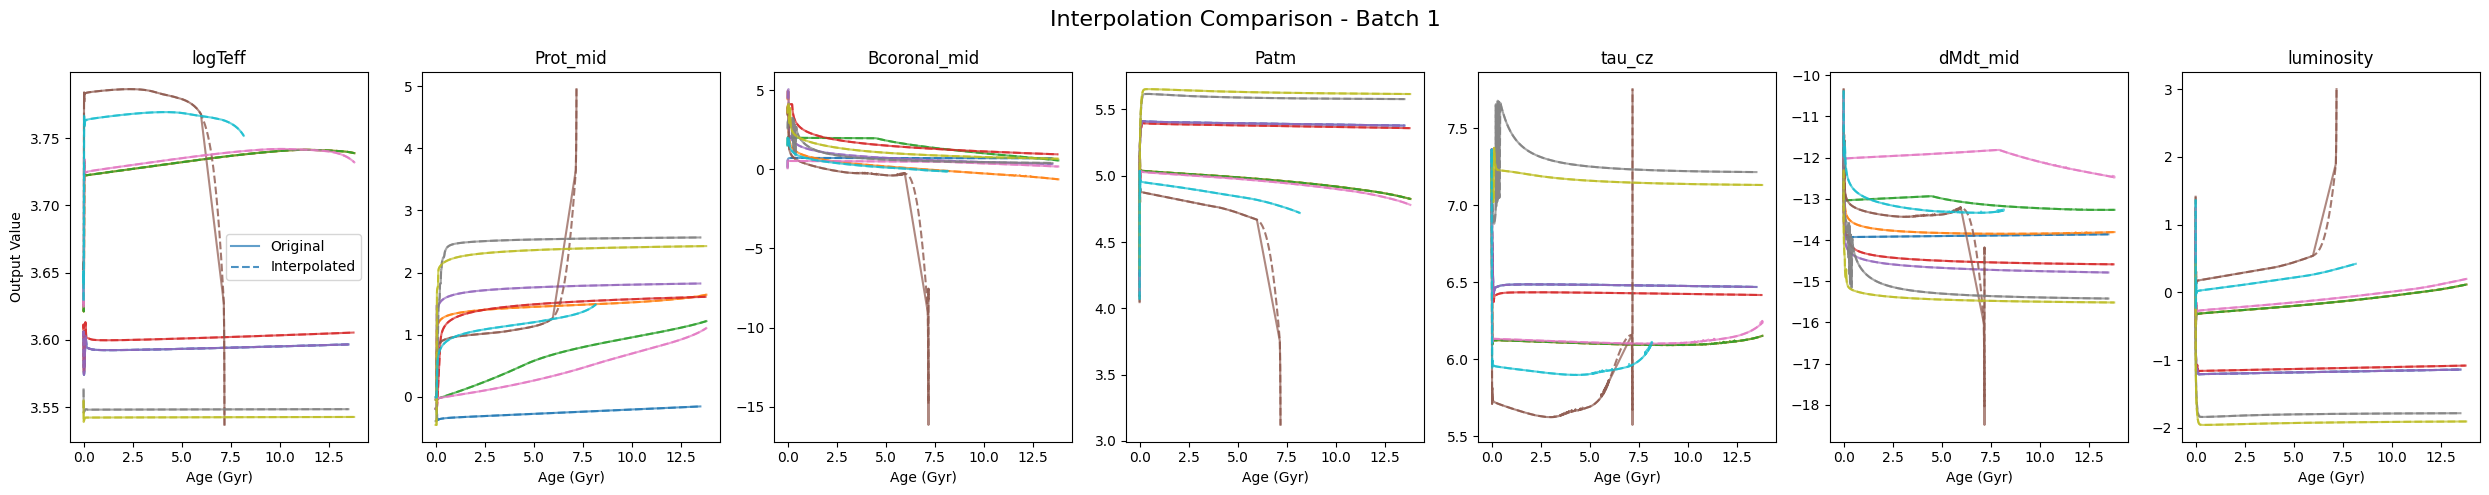

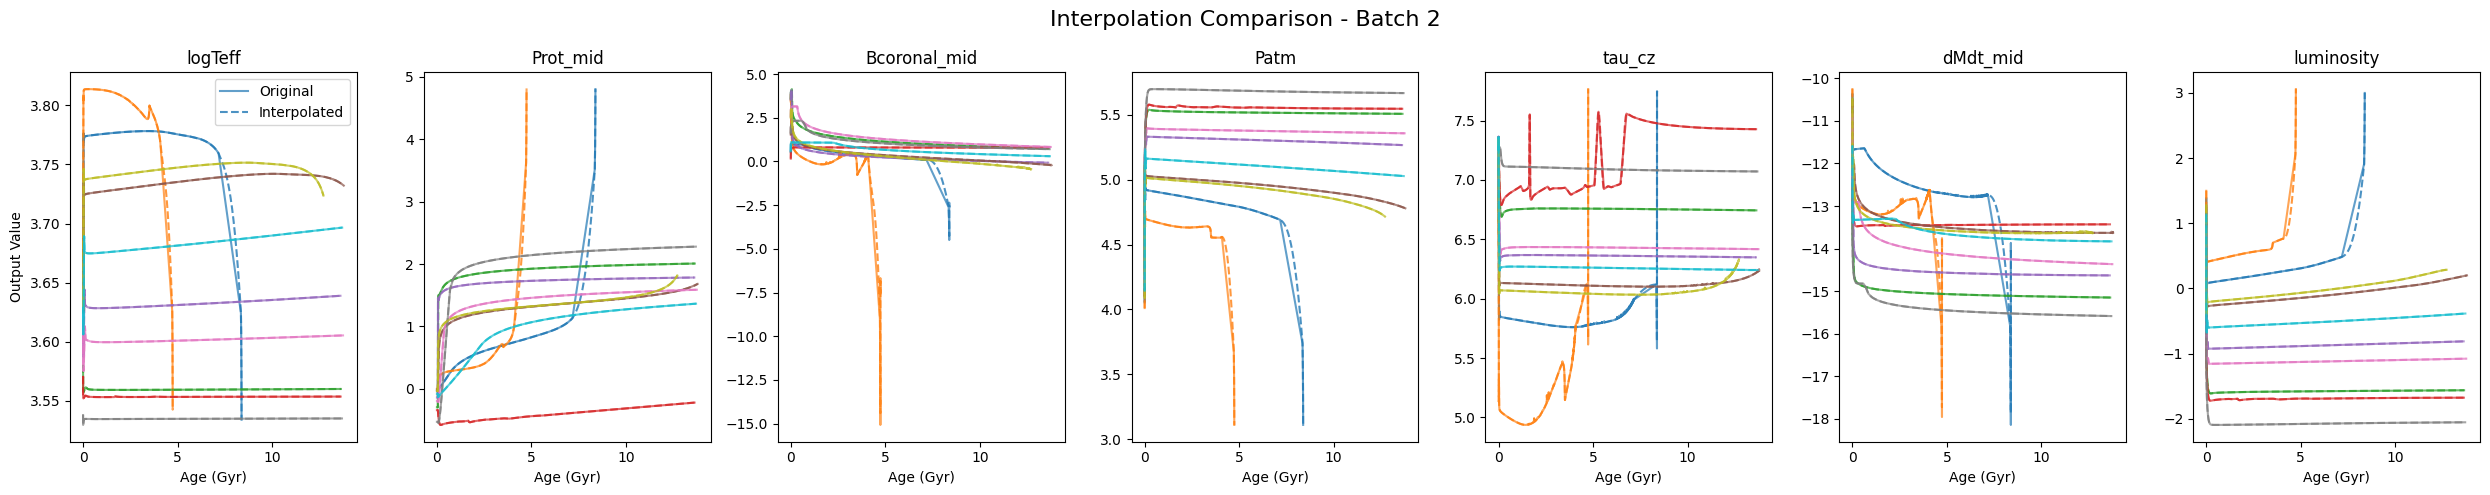

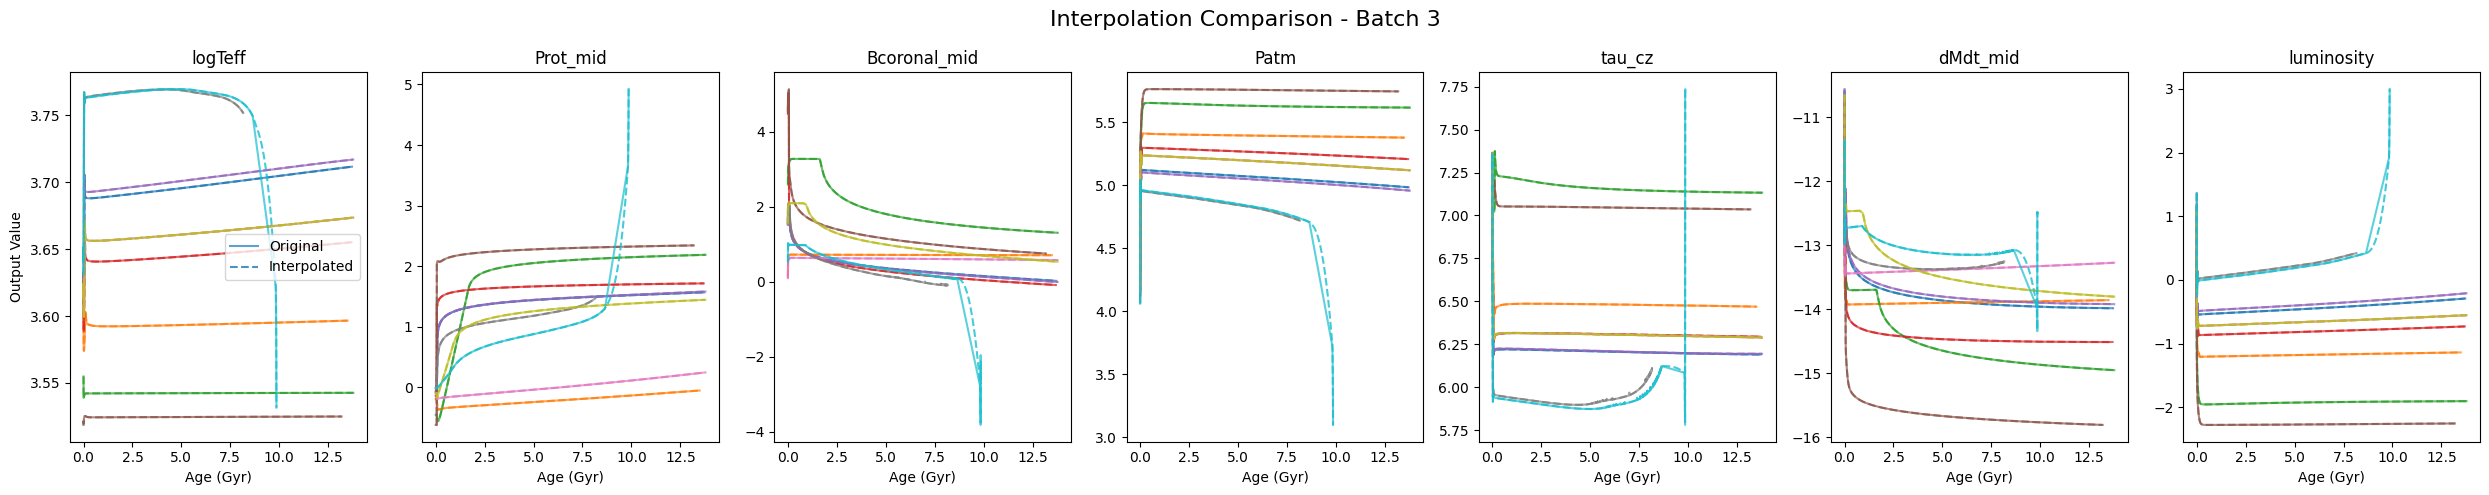

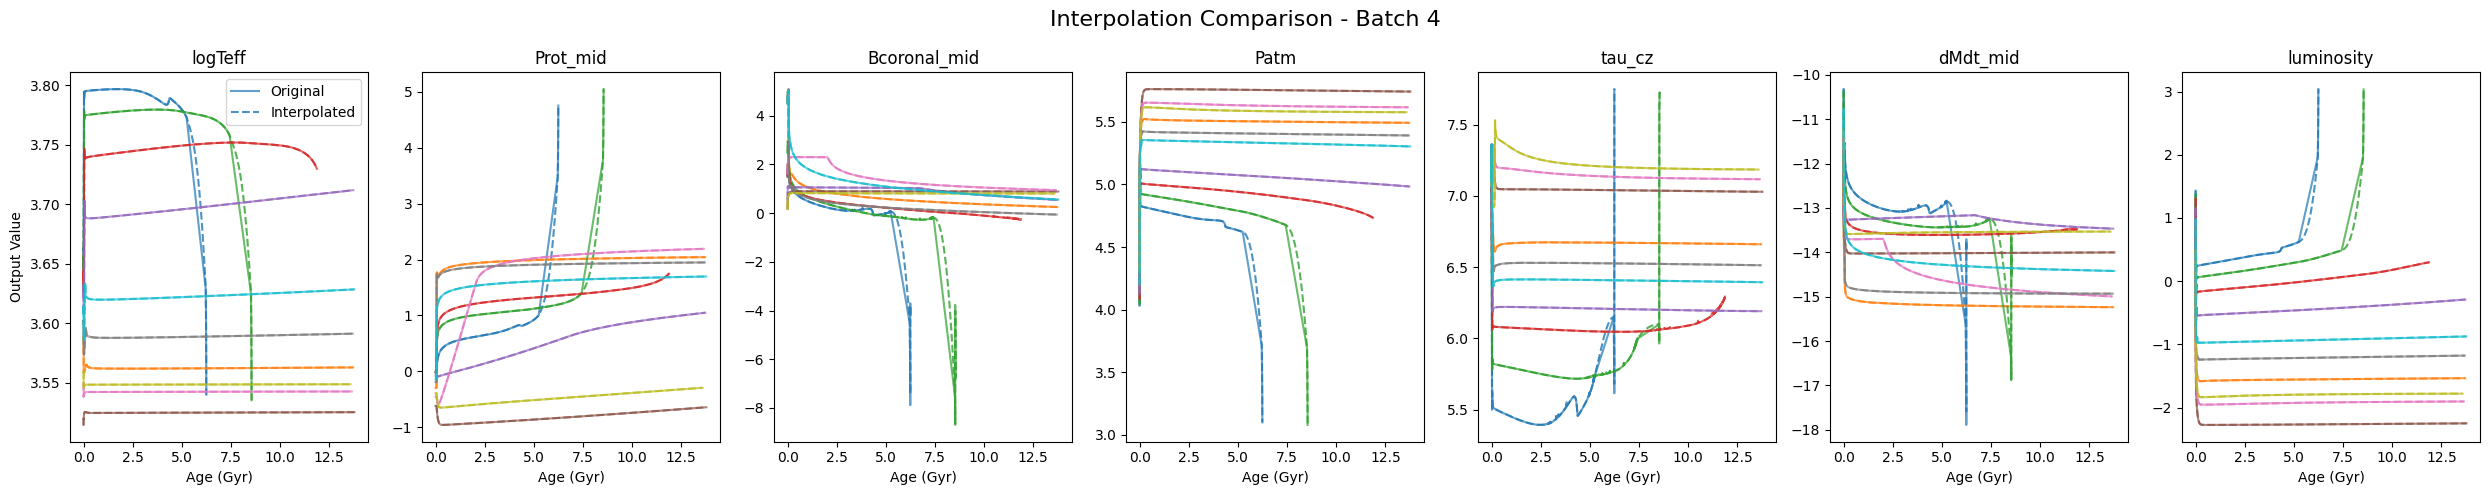

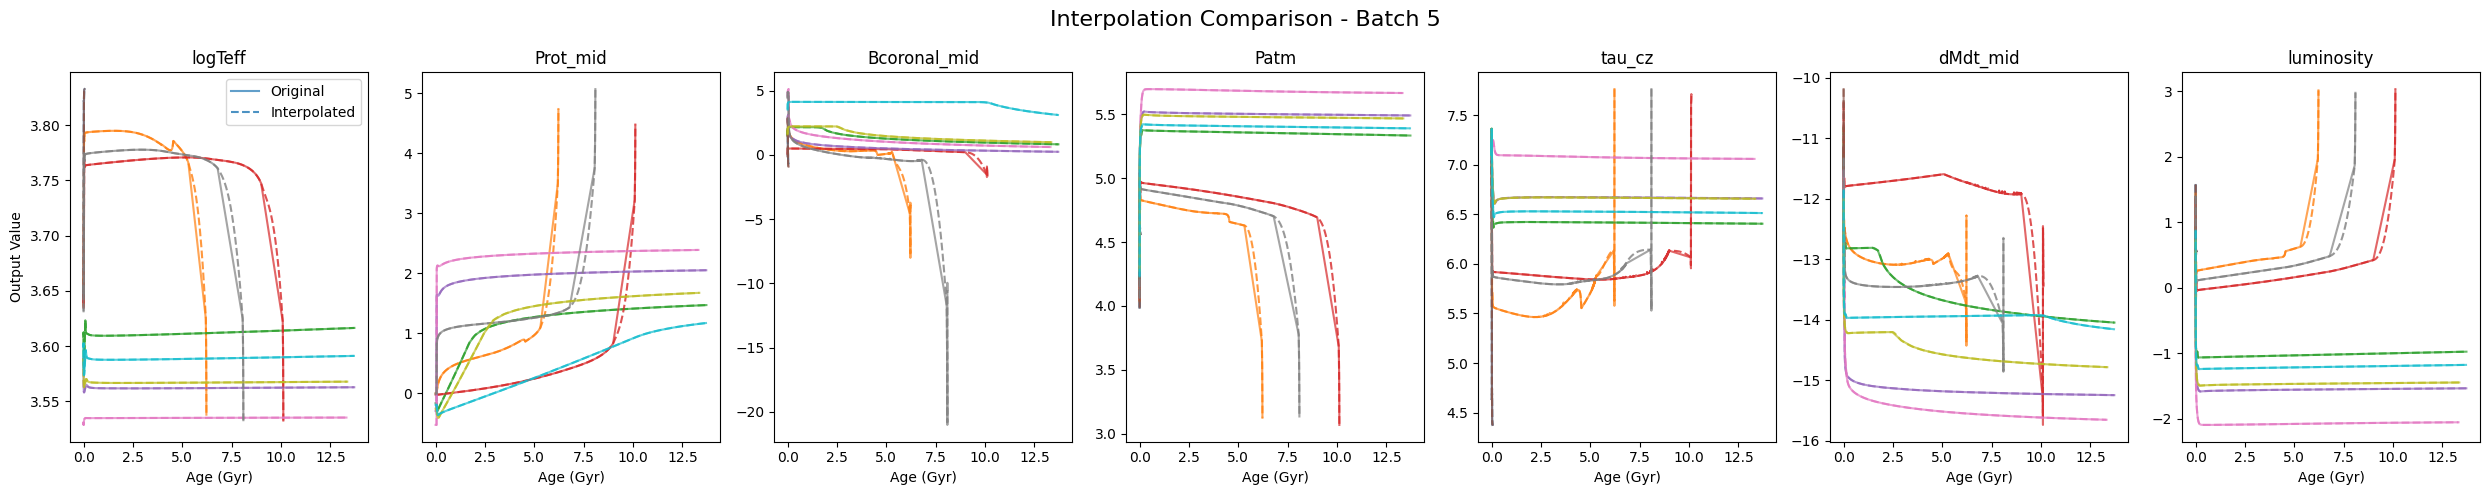

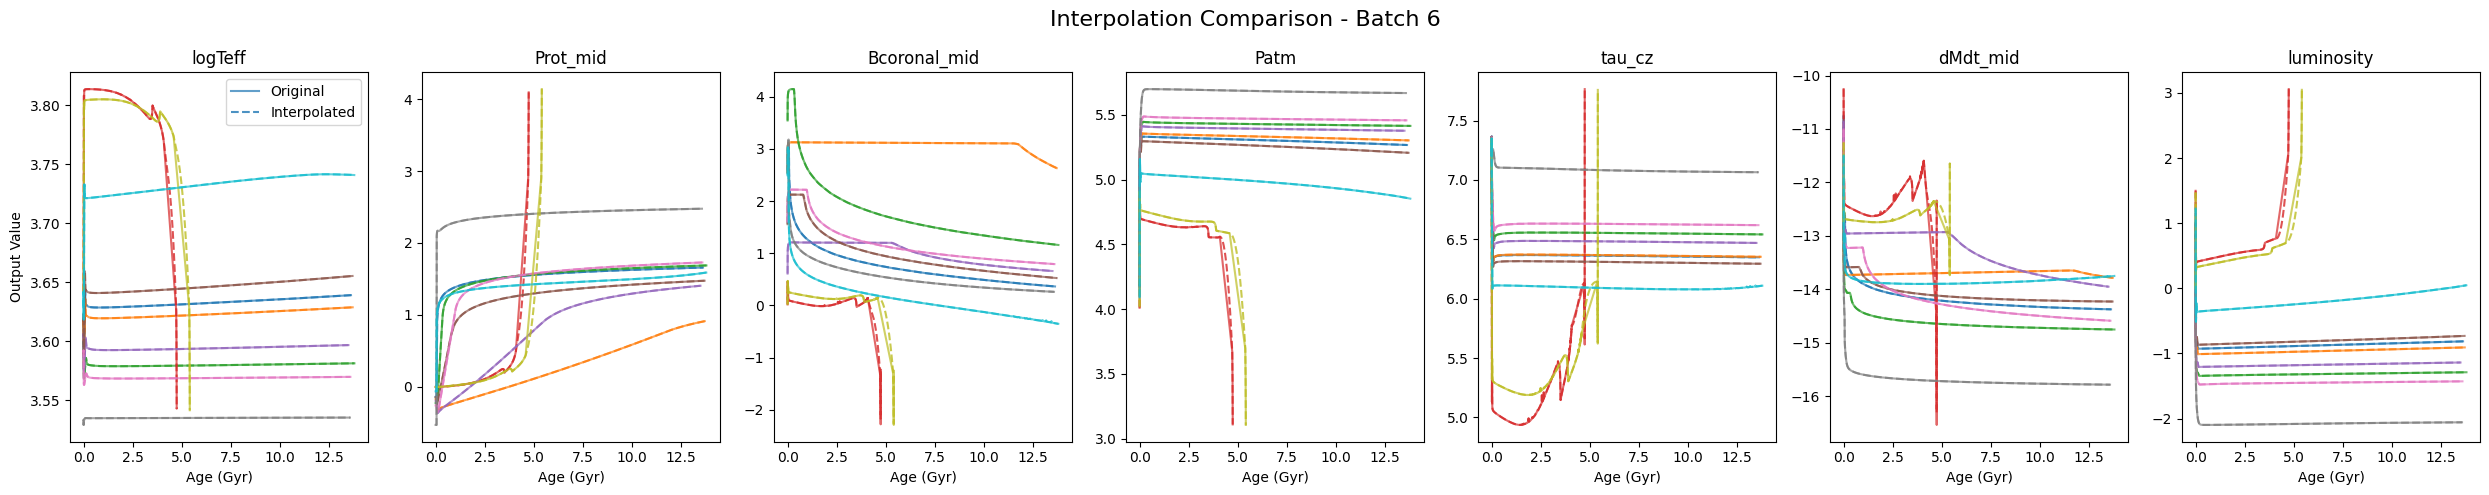

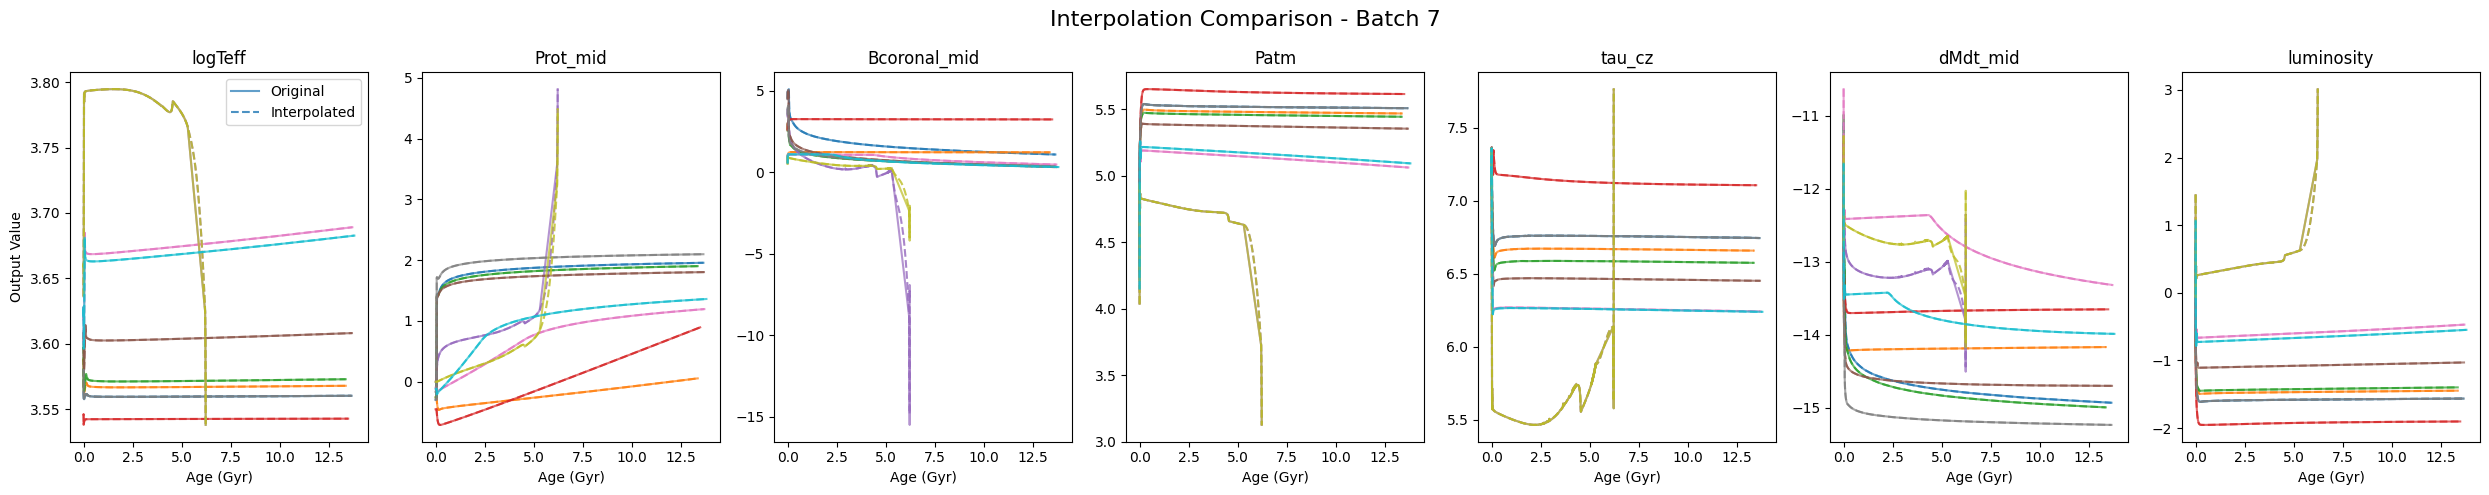

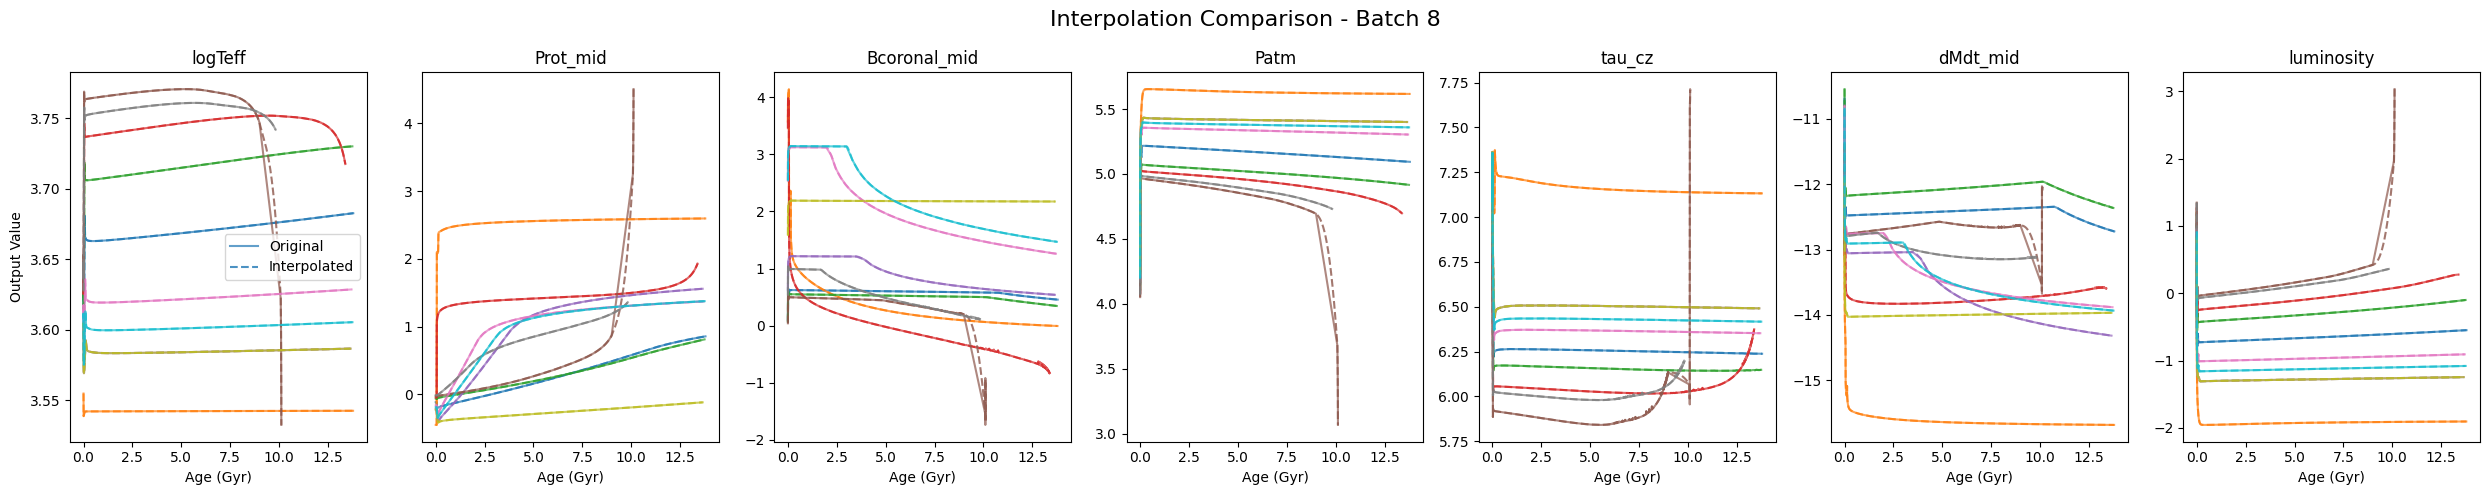

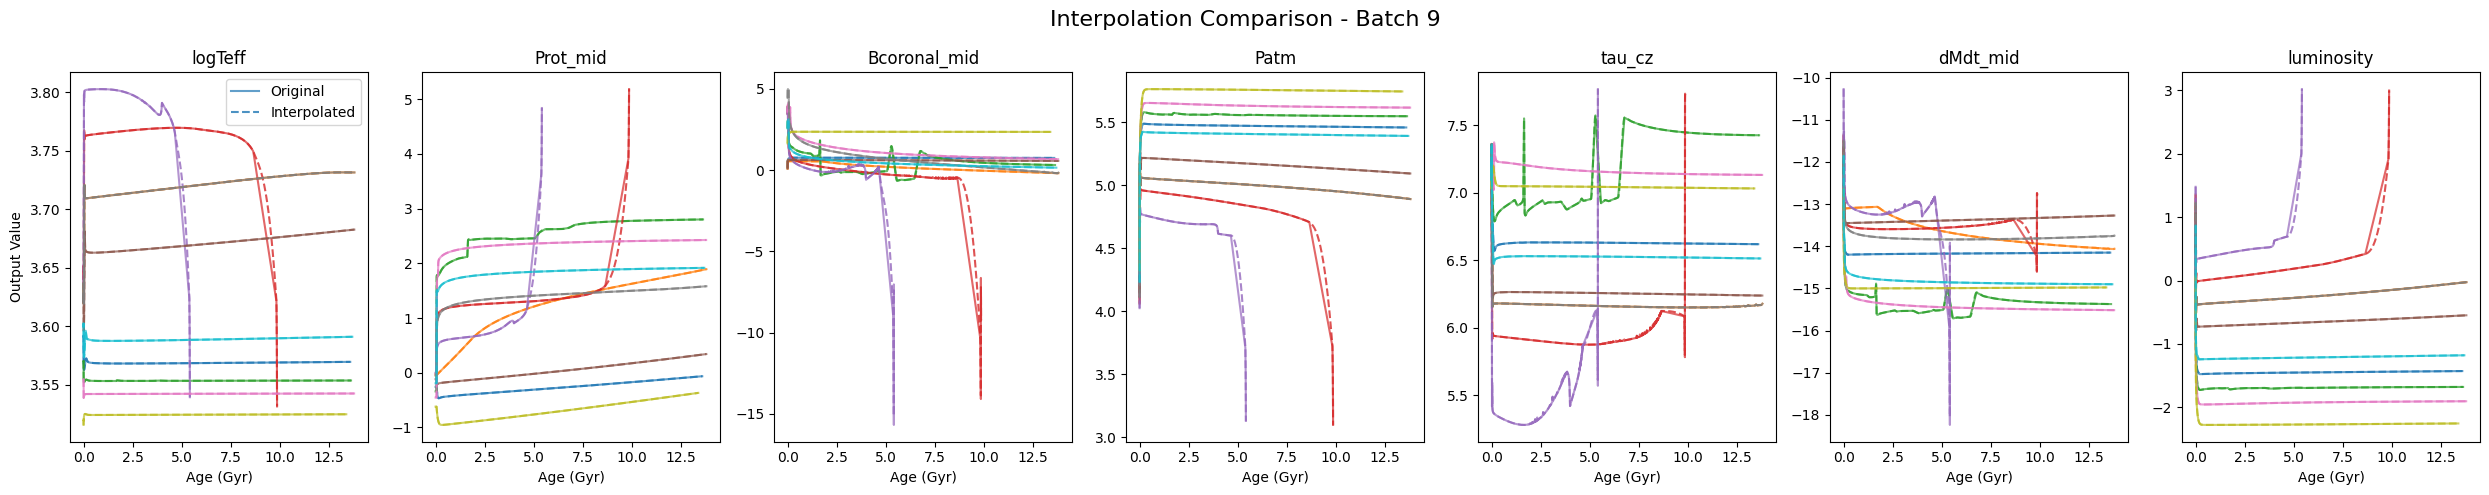

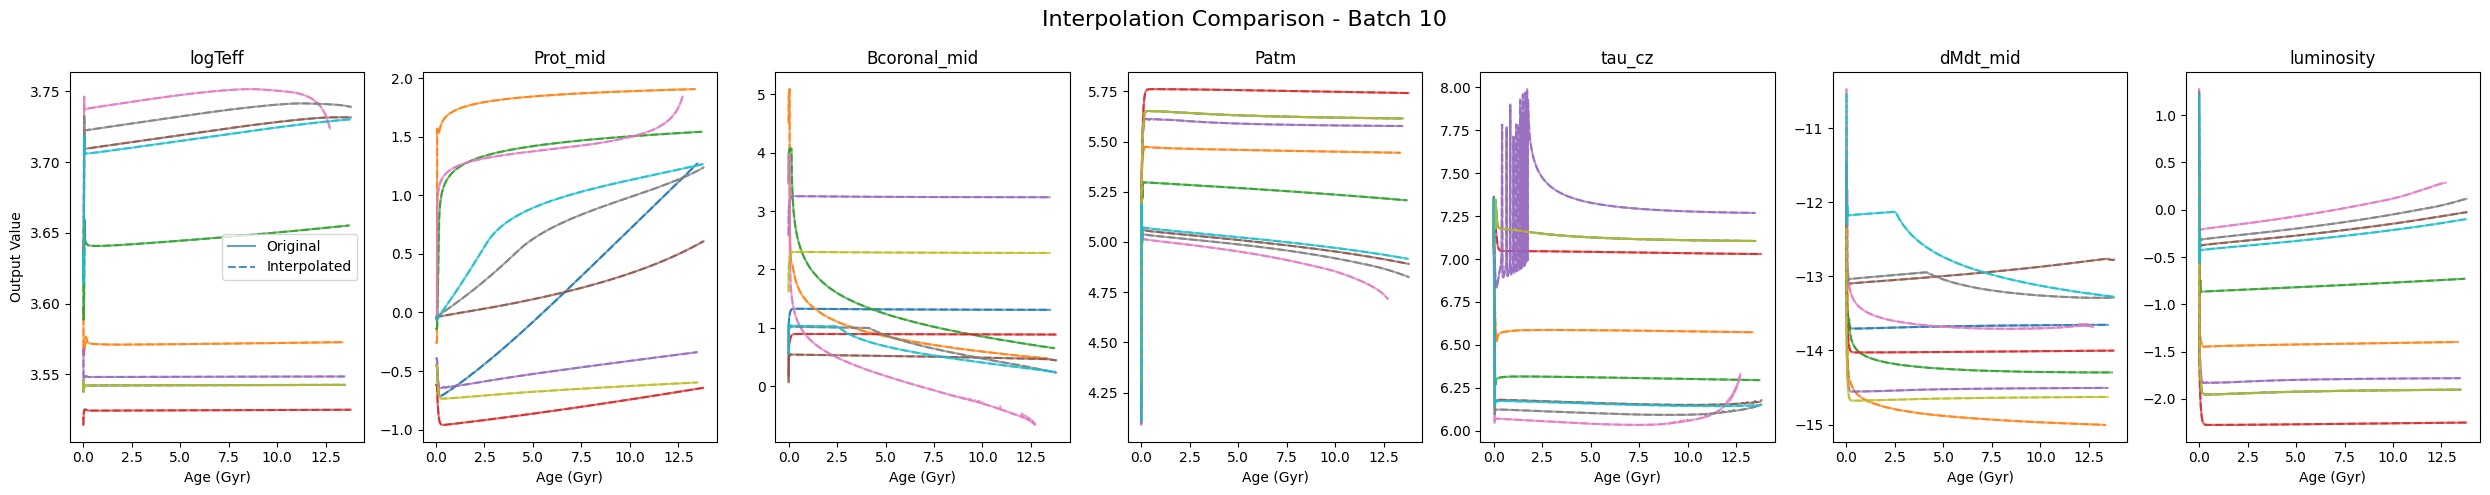

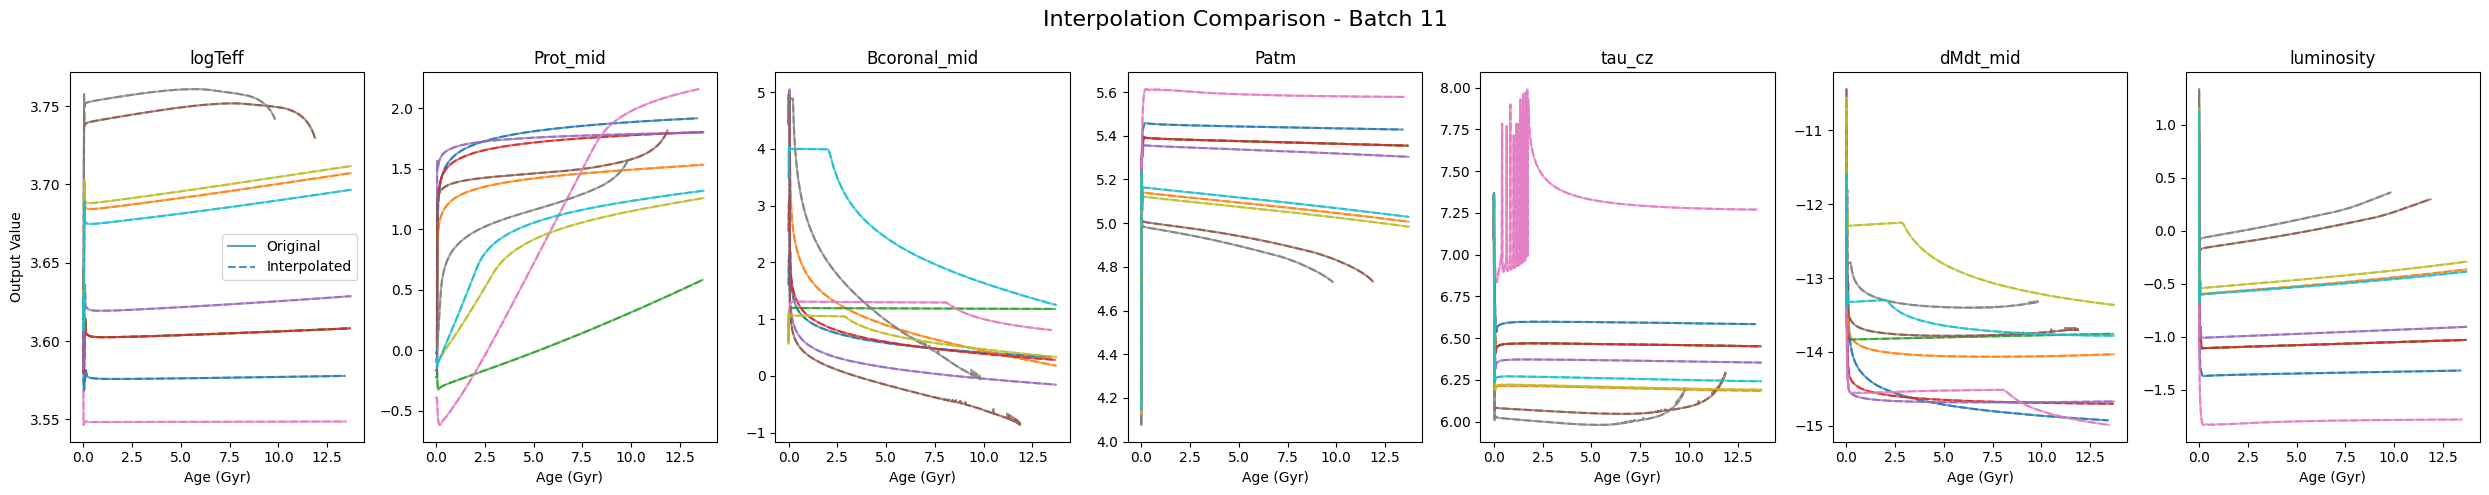

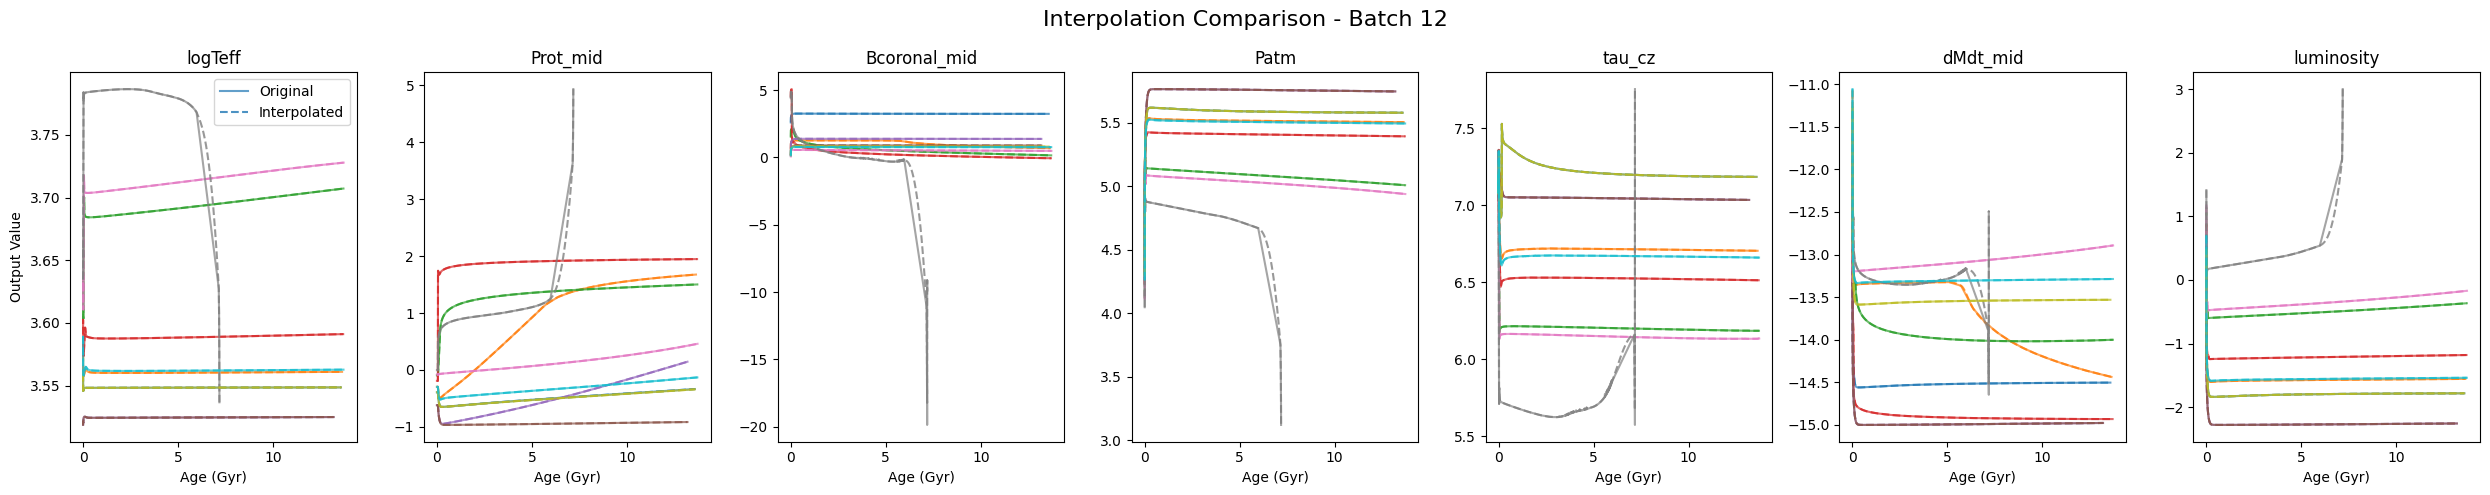

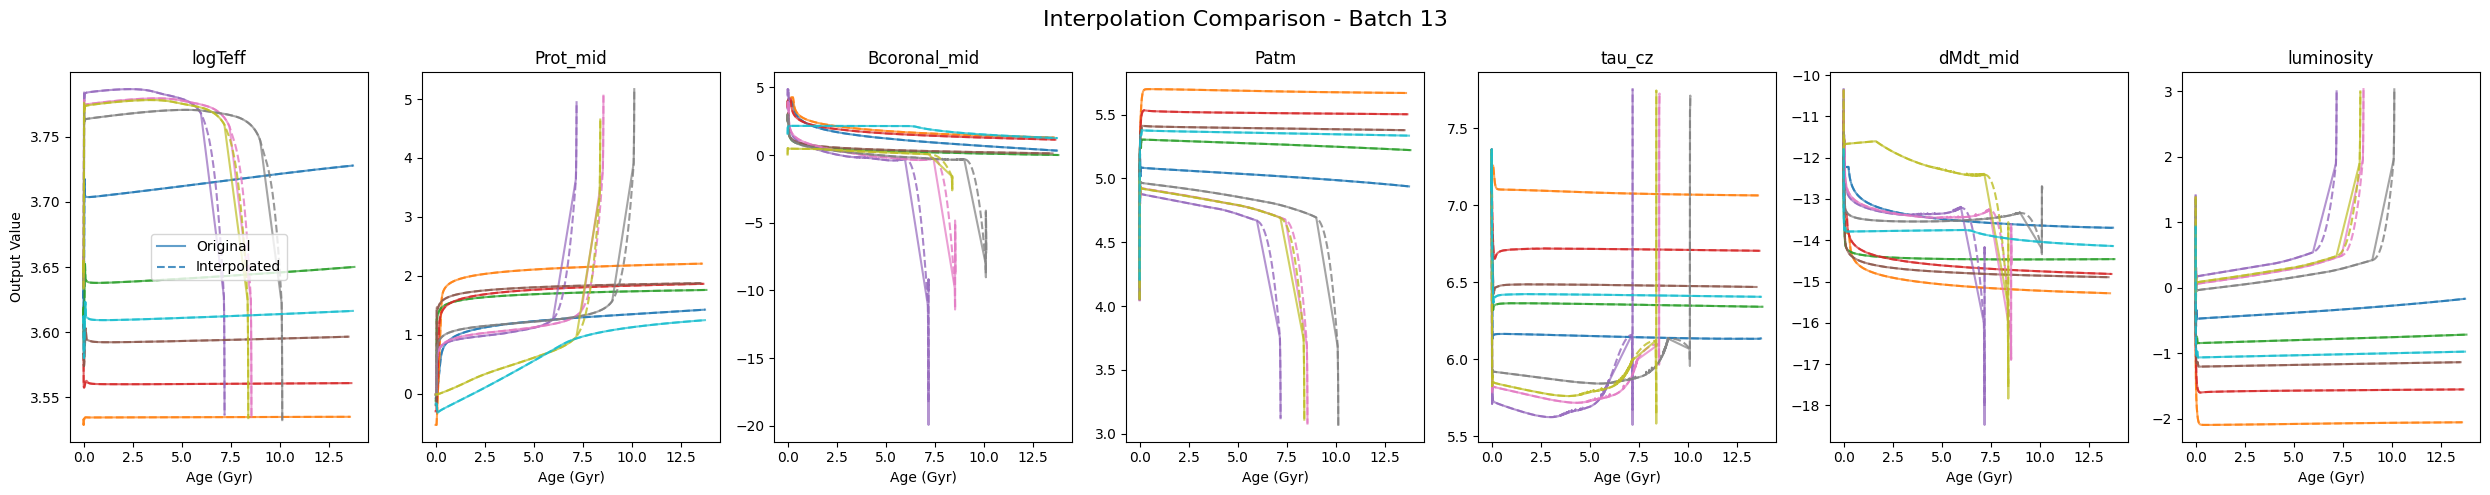

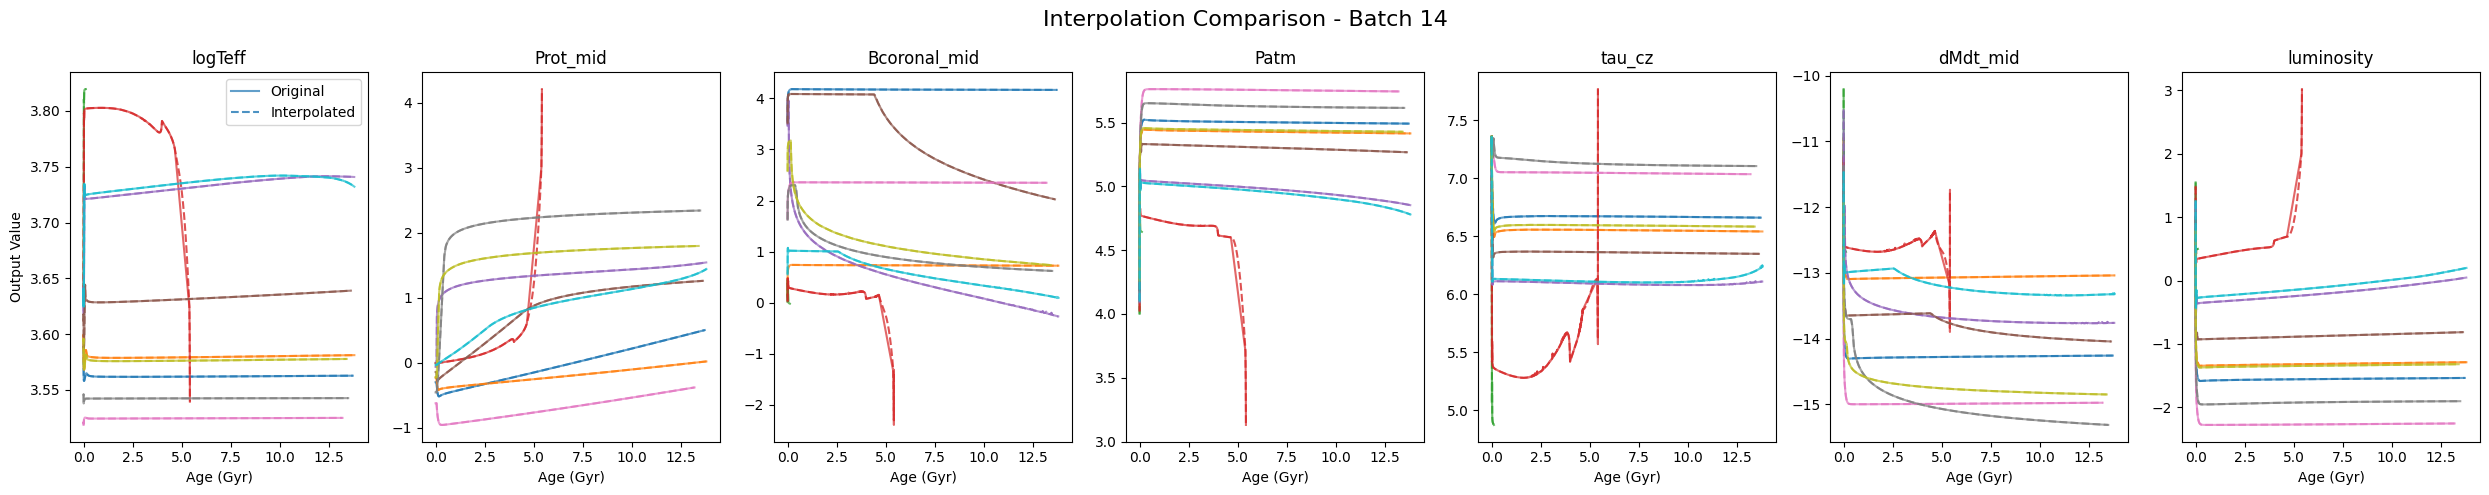

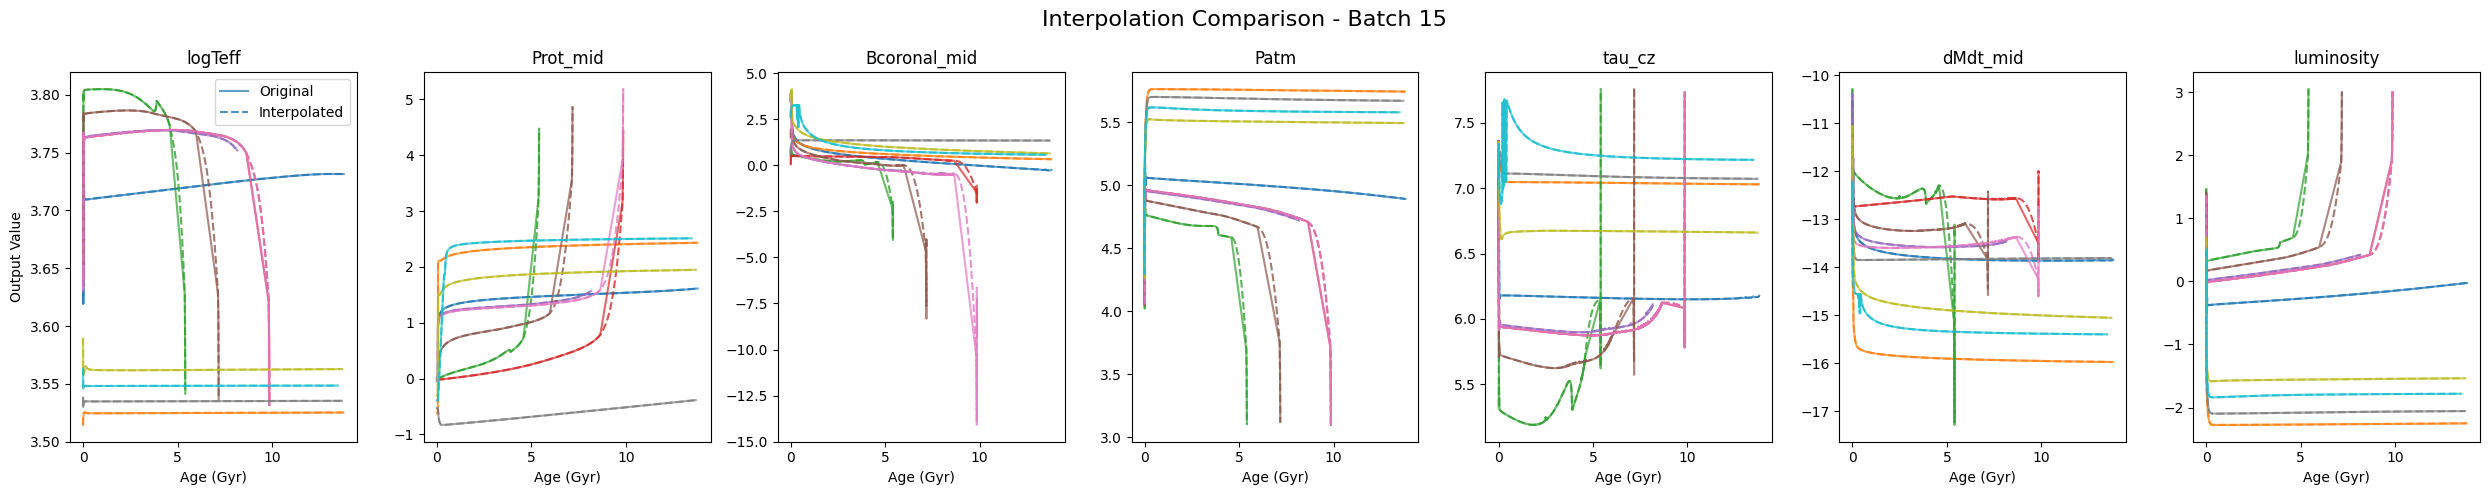

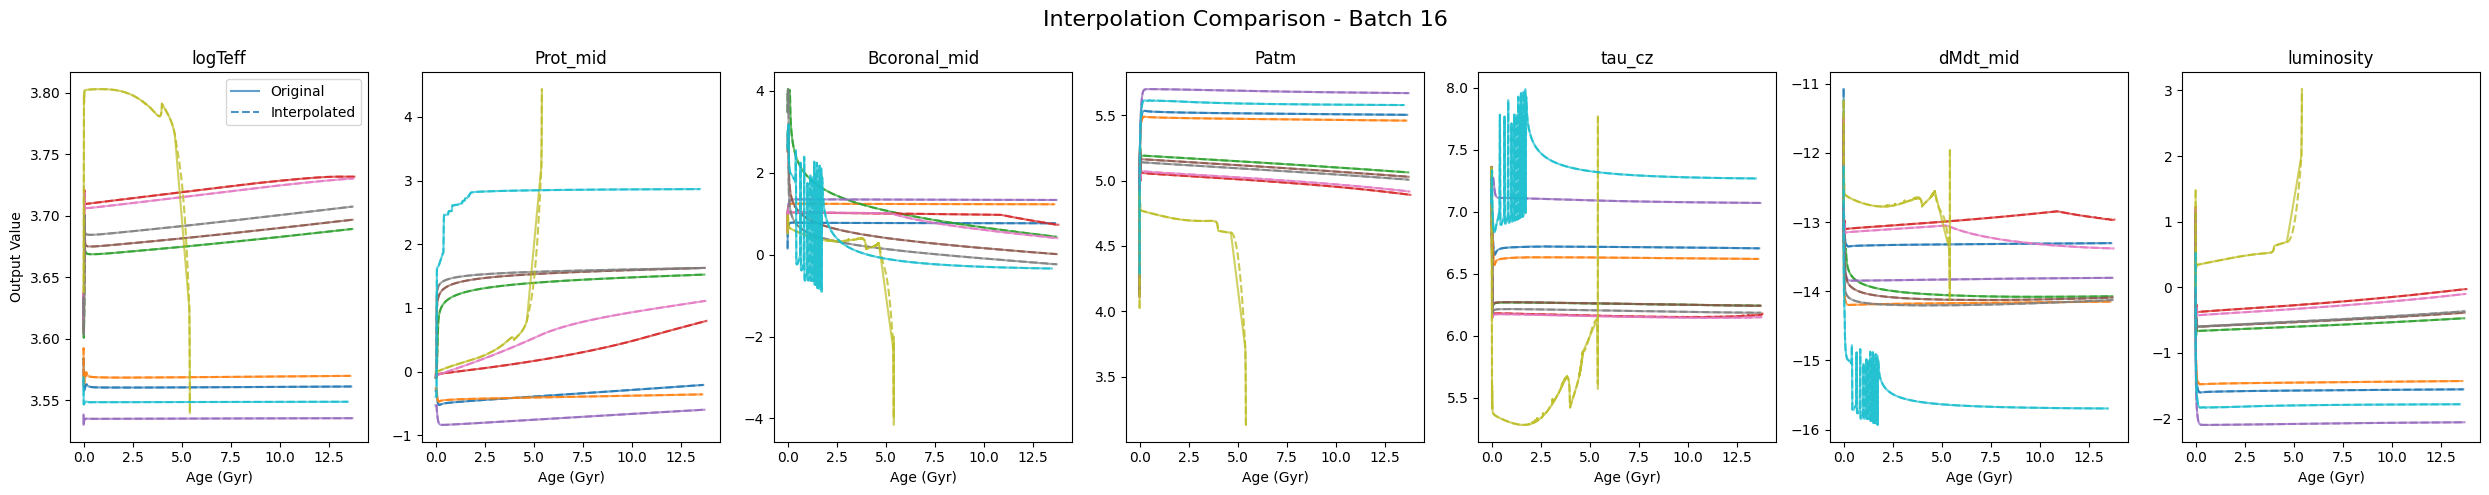

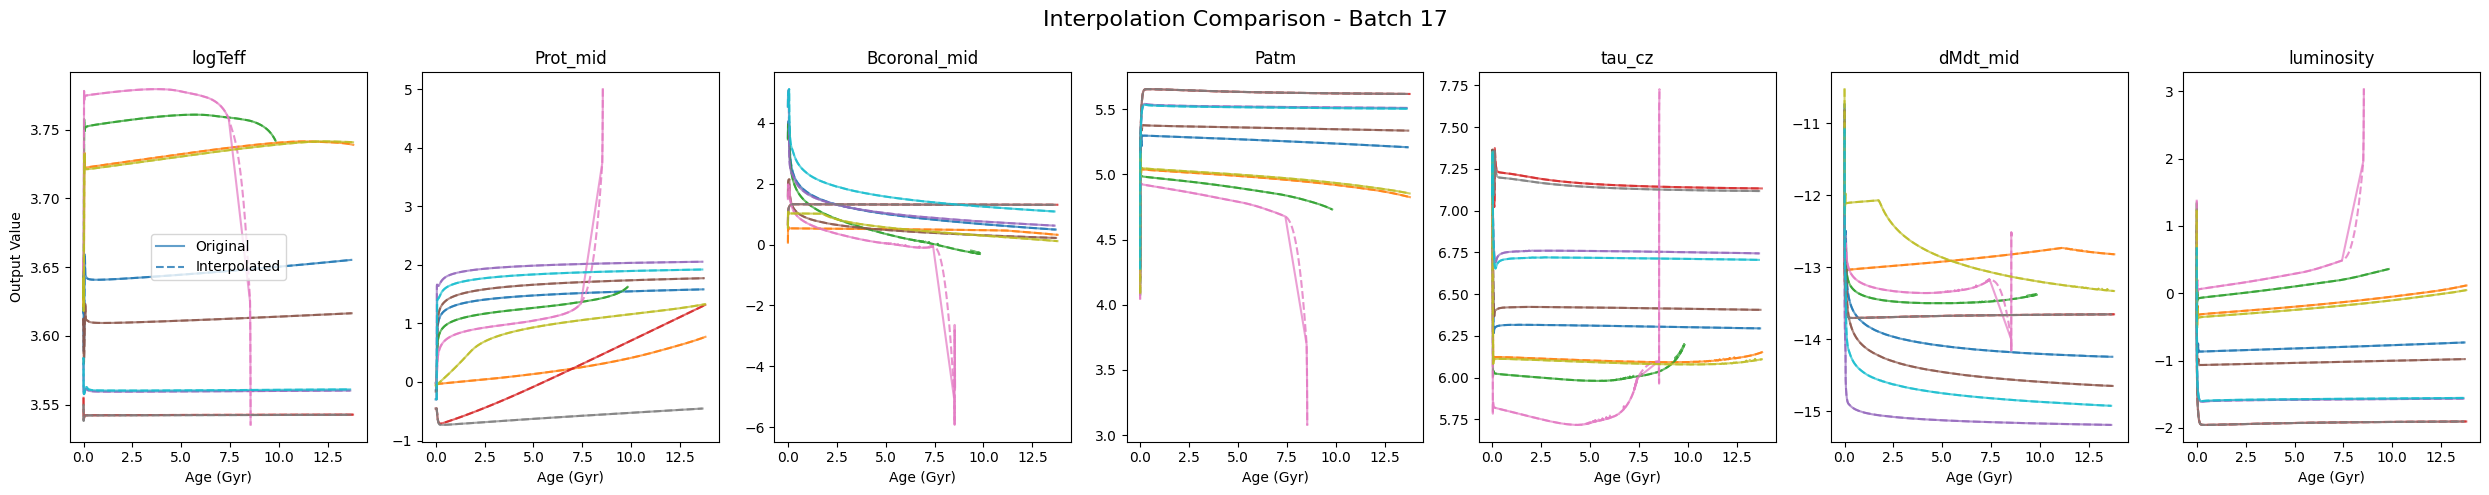

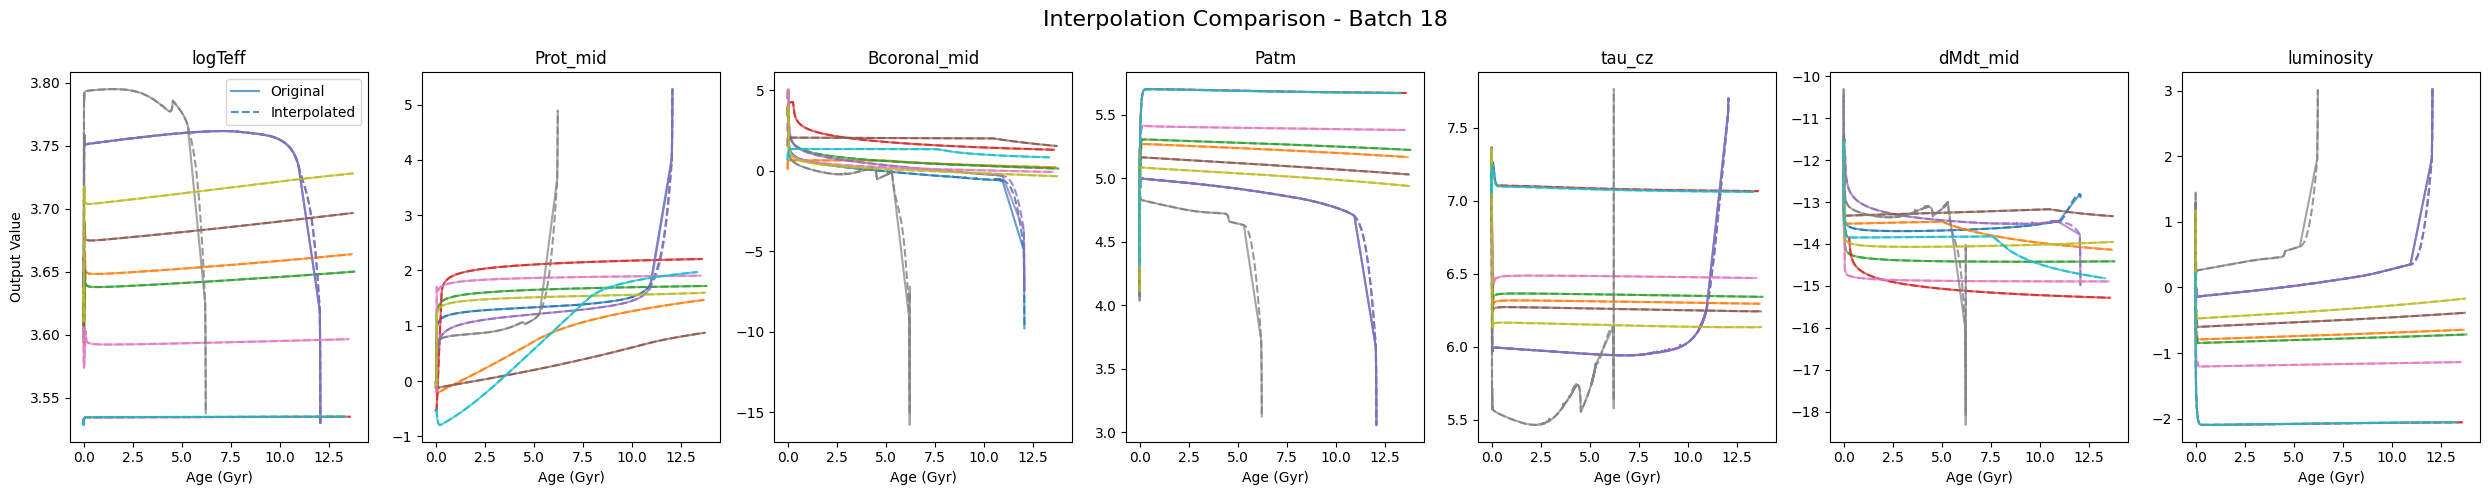

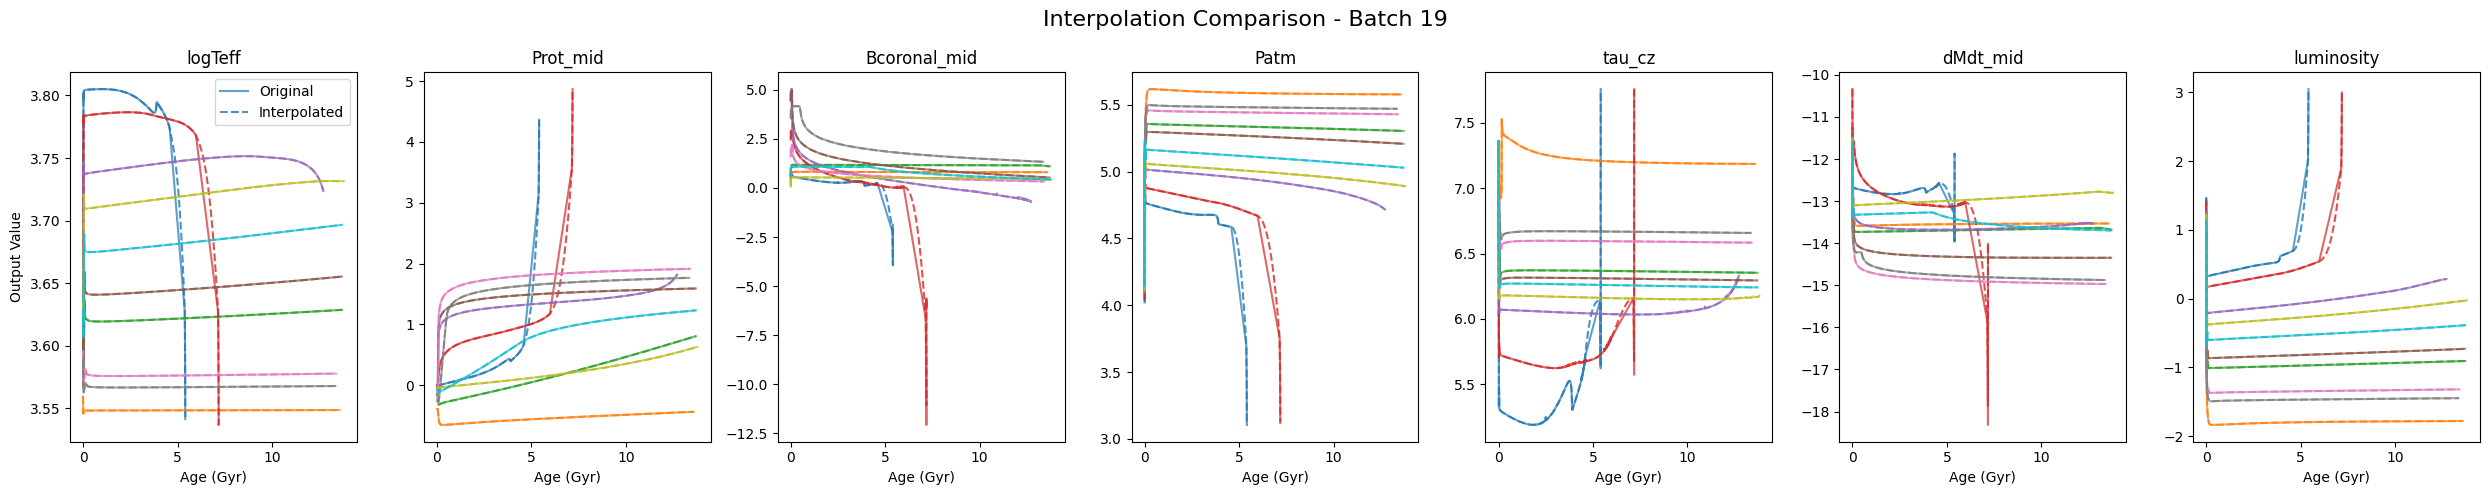

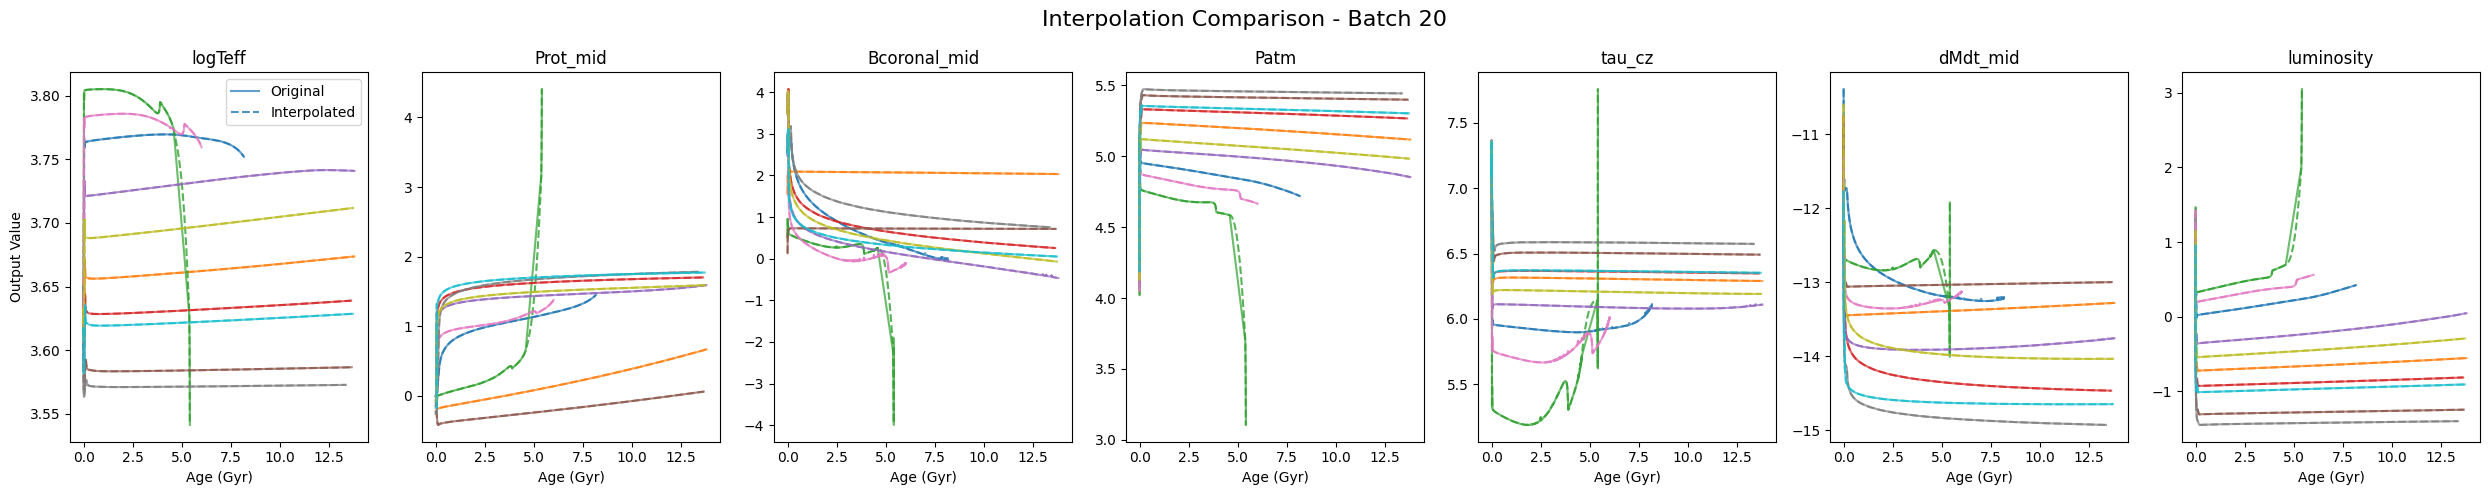

In [62]:
# ...existing code...
num_figures = 20      # Number of separate images to generate
sims_per_fig = 10     # Number of simulations to overlay in each image
colors = plt.cm.tab10.colors

for fig_idx in range(num_figures):
    # Select a random subset of simulations for this figure
    rng = np.random.default_rng(seed=SEED+fig_idx+2)  # Create a new random generator for reproducibility
    sim_indices = rng.choice(len(df_train), size=sims_per_fig, replace=False)
    
    fig = plt.figure(figsize=(25, 5))
    fig.suptitle(f'Interpolation Comparison - Batch {fig_idx + 1}', fontsize=16)
    
    for j in range(len(output_cols)):
        ax = fig.add_subplot(1, len(output_cols), j+1)
        
        for k, sim_idx in enumerate(sim_indices):
            # Only add labels for the first simulation to avoid duplicate legend entries
            label_orig = 'Original' if k == 0 else None
            label_new = 'Interpolated' if k == 0 else None
            
            # Plot Original (solid line)
            ax.plot(10**df_train['Age'][sim_idx], df_train['output'][sim_idx][:, j], 
                    linestyle='-', color=colors[k], alpha=0.7, label=label_orig)
            
            # Plot Interpolated (dashed line)
            ax.plot(10**df_train['New_Age'][sim_idx], df_train['New_output'][sim_idx][:, j], 
                    linestyle='--', color=colors[k], alpha=0.8, label=label_new)
        
        ax.set_title(output_cols[j])
        ax.set_xlabel('Age (Gyr)')
        if j == 0:
            ax.set_ylabel('Output Value')
            ax.legend()
            
    plt.tight_layout()
    plt.show()
# ...existing code...

In [16]:
len(df_train)

4320

In [ ]:
print('time_test shape:', array_new_age.shape)
print('output_test shape:', new_output.shape)
print('initial_conditions shape:', df_train[initial_conditions].values.shape)
os.makedirs(directory_output_name, exist_ok=True)
print('Saving preprocessed data to:', directory_output_name)
np.save(os.path.join(directory_output_name, 'time.npy'), array_new_age)
np.save(os.path.join(directory_output_name, 'output.npy'), new_output)
np.save(os.path.join(directory_output_name, 'initial_conditions.npy'), df_train[initial_conditions].values)

if plot_examples:
    os.makedirs(directory_plot_examples, exist_ok=True)
    # Plot examples of the original and new age distributions for a few simulations
    num_examples = 10
    rng = np.random.default_rng(13)
    examples = rng.integers(low=0, high=len(df_train), size=num_examples)
    plt.figure(figsize=(25, 4))
    for idx, sim_idx in enumerate(examples):
        plt.subplot(1, len(examples), idx+1)
        plt.hist(df_train['Age'][sim_idx], bins=30, histtype='step',  label='Original Age', density=True)
        plt.hist(df_train['New_Age'][sim_idx], bins=30, histtype='step',  label='New Age (KDE)',density=True )
        plt.title(f'Simulation {sim_idx+1}')
        plt.xlabel('Age (Gyr)')
        plt.ylabel('Frequency')
        if idx == 0:
            plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(directory_plot_examples, 'age_distributions_examples.png'))
    plt.show()

    fig = plt.figure(figsize=(25, 4))
    colors = plt.cm.tab10.colors[:len(examples)]
    for j in range(len(output_cols)):
        ax = fig.add_subplot(1, len(output_cols), j+1)
        for idx, sim_idx in enumerate(examples):
            # Only add labels for the first simulation to avoid duplicate legend entries
            label_orig = 'Original Output' if idx == 0 else None
            label_new = 'New Output (Interpolated)' if idx == 0 else None
            
            ax.plot(10**df_train['Age'][sim_idx], df_train['output'][sim_idx][:, j], label=label_orig, linestyle="-", color=colors[idx])
            # ax.plot(10**df_train['New_Age'][sim_idx], new_output[sim_idx, :, j], label=label_new, linestyle="--", color=colors[idx])
            # ax.scatter(10**df_train['New_Age'][sim_idx], new_output[sim_idx, :, j], label=label_new, s=15, color=colors[idx])

            
        ax.set_title(output_cols[j])
        ax.set_xlabel('Age (Gyr)')
        ax.set_ylabel(output_cols[j])
        if j == 0: 
            ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(directory_plot_examples, 'output_interpolation_examples.png'))
    plt.show()
